In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency, f_oneway

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)  
pd.set_option('display.max_rows', None)  

In [2]:
df = pd.read_csv('C:/Users/xavis/Xavier/Benestar-e/DATA/DADES_EXCEL_TOTS.csv', sep=';', encoding='latin1')
print(df.shape)
df.head()

(1778, 250)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic, )_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic, )_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,\nTranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100
0,1.0,1.0,18.0,1.0,1.0,1.0,4.0,2.0,NaN,NaN,NaN,NaN,1.0,1.0,1.0,0.0,0.0,0.0,0.0,21.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,2.0,6.0,52.0,56.0,53.0,53.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0,4.0,3.0,4.0,4.0,5.0,4.0,5.0,5.0,3.0,4.0,3.0,4.0,5.0,4.0,5.0,5.0,5.0,5.0,3.0,3.0,4.0,5.0,4.0,2.0,4.0,5.0,5.0,4.0,5.0,4.0,4.0,44.0,38.0,28.0,27.0,137.0,2.0,78.79,0.0,0.0,0.0,1.0,5.0,0.0,6.0,0.0,0.0,5.0,6.0,6.0,0.0,0.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,0.00,5.67,1.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,6.0,5.0,6.0,7.0,31.0,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
ARS = df[df['GRUP'] == 2]
print(ARS.shape)
ARS.head()

(197, 250)


,ID,GRUP,record_id,genere,edat_categorica,nacionalitat,salud,situacio_economica,contracte_uvic,antiguitat,pdi_pas,centre_pas,centre_pdi_estudiant,centre_estudiant,estudis_uvic___1,estudis_uvic___2,estudis_uvic___3,estudis_uvic___4,estudis_uvic___5,graus,curs___1,curs___2,curs___3,curs___4,curs___5,curs___6,curs___7,situacio_laboral,BSI1,BSI2,BSI3,BSI4,BSI5,BSI6,BSI7,BSI8,BSI9,BSI10,BSI11,BSI12,BSI13,BSI14,BSI15,BSI16,BSI17,BSI18,BSI_Somatització_PD,BSI_Depresió_PD,BSI_Ansietat_PD,BSI_IGS_PD,BSI_Somatització_PT,BSI_Depresió_PT,BSI_Ansietat_PT,BSI_IGS_PT,BSI_Somatització_Clínic,BSI_Depresió_Clínic,BSI_Ansietat_Clínic,BSI_IGS_Clínic,Pregunta BSI_17_Clínic_suïcidi,BSI_Clínic_suïcidi,sseit1,sseit2,sseit3,sseit4,sseit5,sseit6,sseit7,sseit8,sseit9,sseit10,sseit11,sseit12,sseit13,sseit14,sseit15,sseit16,sseit17,sseit18,sseit19,sseit20,sseit21,sseit22,sseit23,sseit24,sseit25,sseit26,sseit27,sseit28,sseit29,sseit30,sseit31,sseit32,sseit33,SEEIT_PERCEPCIO,SEEIT_GESTIO_PROPIES_EMOCIONS,SEEIT_GESTIO_EMOCIONS_ALTRES,SEEIT_US_EMOCIONS,SEEIT_PT,SEEIT_Nivell,SEEIT_PT_N100,MBI_SS_1,MBI_SS_2,MBI_SS_3,MBI_SS_4,MBI_SS_5,MBI_SS_6,MBI_SS_7,MBI_SS_8,MBI_SS_9,MBI_SS_10,MBI_SS_11,MBI_SS_12,MBI_SS_13,MBI_SS_14,MBI_SS_15,MBI_GS_1,MBI_GS_2,MBI_GS_3,MBI_GS_4,MBI_GS_5,MBI_GS_6,MBI_GS_7,MBI_GS_8,MBI_GS_9,MBI_GS_10,MBI_GS_11,MBI_GS_12,MBI_GS_13,MBI_GS_14,MBI_GS_15,Agotament_emocional,Cinisme,Realització personal,Nivell_agotament_emocional,Nivell_Cinisme-,Nivell_Realització personal,Clínic_Agotament_emocional,Clínic_Cinisme,Clínic_Realització personal,MBI_Clínic_2d3,MBI_Clínic_2d2,MBI_Clínic_ 3d3,swls1,swls2,swls3,swls4,swls5,SWLS_PT,SWLS_PT_N100,wcw1,wcw2,wcw3,wcw4,wcw5,wcw6,wcw7,wcw8,wcw9,wcw10,wcw11,wcw12,wcw13,wcw14,wcw15,Satisfaccio_intrinseca,Satisfacció_extrinseca,Satisfaccio_laboral_PT,Satisfaccio_laboral_PT_N100,WCW_Nivell,esa1,esa2,esa3,esa4,esa5,esa6,esa7,esa8,ESA_PT,ESA_Nivell,ESA_PT_N100,esport,temps_esport,hores_fisic,Canya_dia_habitual,Mitjana_dia_habitual,Copa de vi_dia_habitual,Copa de cava/champany_dia_habitual,"Combinats (gin-tonic, )_dia_habitual","Copa (ron, vodka, whisky,..)_dia_habitual",Sigaló/Rebentat/Carajillo_dia_habitual,Vermut_dia_habitual,Jerez_dia_habitual,Sidra_dia_habitual,marxa,Canya_dia_marxa,Mitjana_dia_marxa,Copa de vi_dia_marxa,Copa de cava/champany_dia_marxa,"Combinats (gin-tonic, )_dia_marxa","Copa (ron, vodka, whisky,..)_dia_marxa",Sigaló/Rebentat/Carajillo_dia_marxa,Vermut_dia_marxa,Jerez_dia_marxa,Sidra_dia_marxa,Dies_marxa_mes,Dies_habituals_mes,UBE_dia_habitual,UBE_dia_maxa,UBE_dieshabitual_mensual,UBE_diesmarxa_mensual,UBE_mensual_total,UBE_habitual_setmanal,UBE_marxa_setmanal,UBE_setmanal_total,risc_alcohol_dia,\nTranquil·litzants/pastilles per dormir,"Cànnabis, marihuana, haixix",Cocaïna,"Èxtasi, drogues de disseny","Al·lucinògens (LSD, tripis, àcid,...)",Amfetamines o Speed,Heroïna,fumador,n_cigarretes_dia,son,dificultats_de_son,remei_son___1,remei_son___2,remei_son___3,remei_son___4,remei_son___5,remei_son___6,remei_son___7,descans,informe,estudis_uvic_RECODIFICATS,curs_uvic_RECODIFICATS,BSI_Somatització_PT_N100,BSI_Depresió_PT_N100,BSI_Ansietat_PT_N100,BSI_IGS_PT_N100,Agotament_emocional_N100,Cinisme_N100,Realizació_personal_N100,BSI_NO_Somatització_PT_N100,BSI_NO_Depresió_PT_N100,BSI_NO_Ansietat_PT_N100,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100
3,4.0,2.0,9.0,1.0,4.0,1.0,3.0,3.0,1.0,5.0,1.0,NaN,4.0,NaN,1.0,0.0,0.0,0.0,0.0,10.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,3.0,55.0,42.0,48.0,49.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,5.0,5.0,4.0,4.0,5.0,1.0,5.0,4.0,5.0,4.0,4.0,5.0,5.0,3.0,4.0,3.0,4.0,5.0,3.0,2.0,5.0,4.0,5.0,4.0,4.0,3.0,5.0,4.0,5.0,4.0,5.0,5.0,43.0,39.0,35.0,20.0,137.0,2.0,78.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,4.0,0.0,1.0,6.0,1.0,6.0,0.0,0.0,6.0,6.0,6.0,0.0,0.0,5.0,1.4,0.00,5.83,2.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,6.0,7.0,6.0,5.0,30.0,83.0,7.0,7.0,7.0,3.0,4.0,6.0,5.0,7.0,4.0,2.0,3

In [4]:
metric_cols = ['ID', 'BSI_NO_IGS_PT_N100', 'NO_Agotament_emocional_N100', 'NO_Cinisme_N100', 'Realizació_personal_N100', 'SEEIT_PT_N100', 'SWLS_PT_N100']

In [5]:
ARS = ARS[metric_cols]
print(ARS.shape)
ARS.head()

(197, 7)


,ID,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,Realizació_personal_N100,SEEIT_PT_N100,SWLS_PT_N100
3,4.0,71.428571,76.666667,100.000000,97.222222,78.79,83.0
4,5.0,52.380952,43.333333,62.500000,83.333333,61.36,53.0
5,6.0,100.000000,86.666667,79.166667,94.444444,65.15,70.0
6,7.0,100.000000,90.000000,100.000000,100.000000,53.03,80.0
9,10.0,39.130435,13.333333,12.500000,61.111111,59.09,63.0


In [6]:
print("Proporción de NaN por columna:")
print(ARS.drop(columns=['ID']).isna().mean().round(3)*100)

Proporción de NaN por columna:
BSI_NO_IGS_PT_N100             2.0
NO_Agotament_emocional_N100    2.0
NO_Cinisme_N100                2.0
Realizació_personal_N100       2.0
SEEIT_PT_N100                  0.0
SWLS_PT_N100                   2.0
dtype: float64


In [7]:
## Remove rows with NaN in any of the metric columns (except ID)

cols_sin_id = [col for col in ARS.columns if col != 'ID']
ARS_df = ARS.dropna(subset=cols_sin_id)
print(f"Number of rows removed: {ARS.shape[0] - ARS_df.shape[0]}")
print(ARS_df.shape)
ARS_df.head()

Number of rows removed: 8
(189, 7)


,ID,BSI_NO_IGS_PT_N100,NO_Agotament_emocional_N100,NO_Cinisme_N100,Realizació_personal_N100,SEEIT_PT_N100,SWLS_PT_N100
3,4.0,71.428571,76.666667,100.000000,97.222222,78.79,83.0
4,5.0,52.380952,43.333333,62.500000,83.333333,61.36,53.0
5,6.0,100.000000,86.666667,79.166667,94.444444,65.15,70.0
6,7.0,100.000000,90.000000,100.000000,100.000000,53.03,80.0
9,10.0,39.130435,13.333333,12.500000,61.111111,59.09,63.0


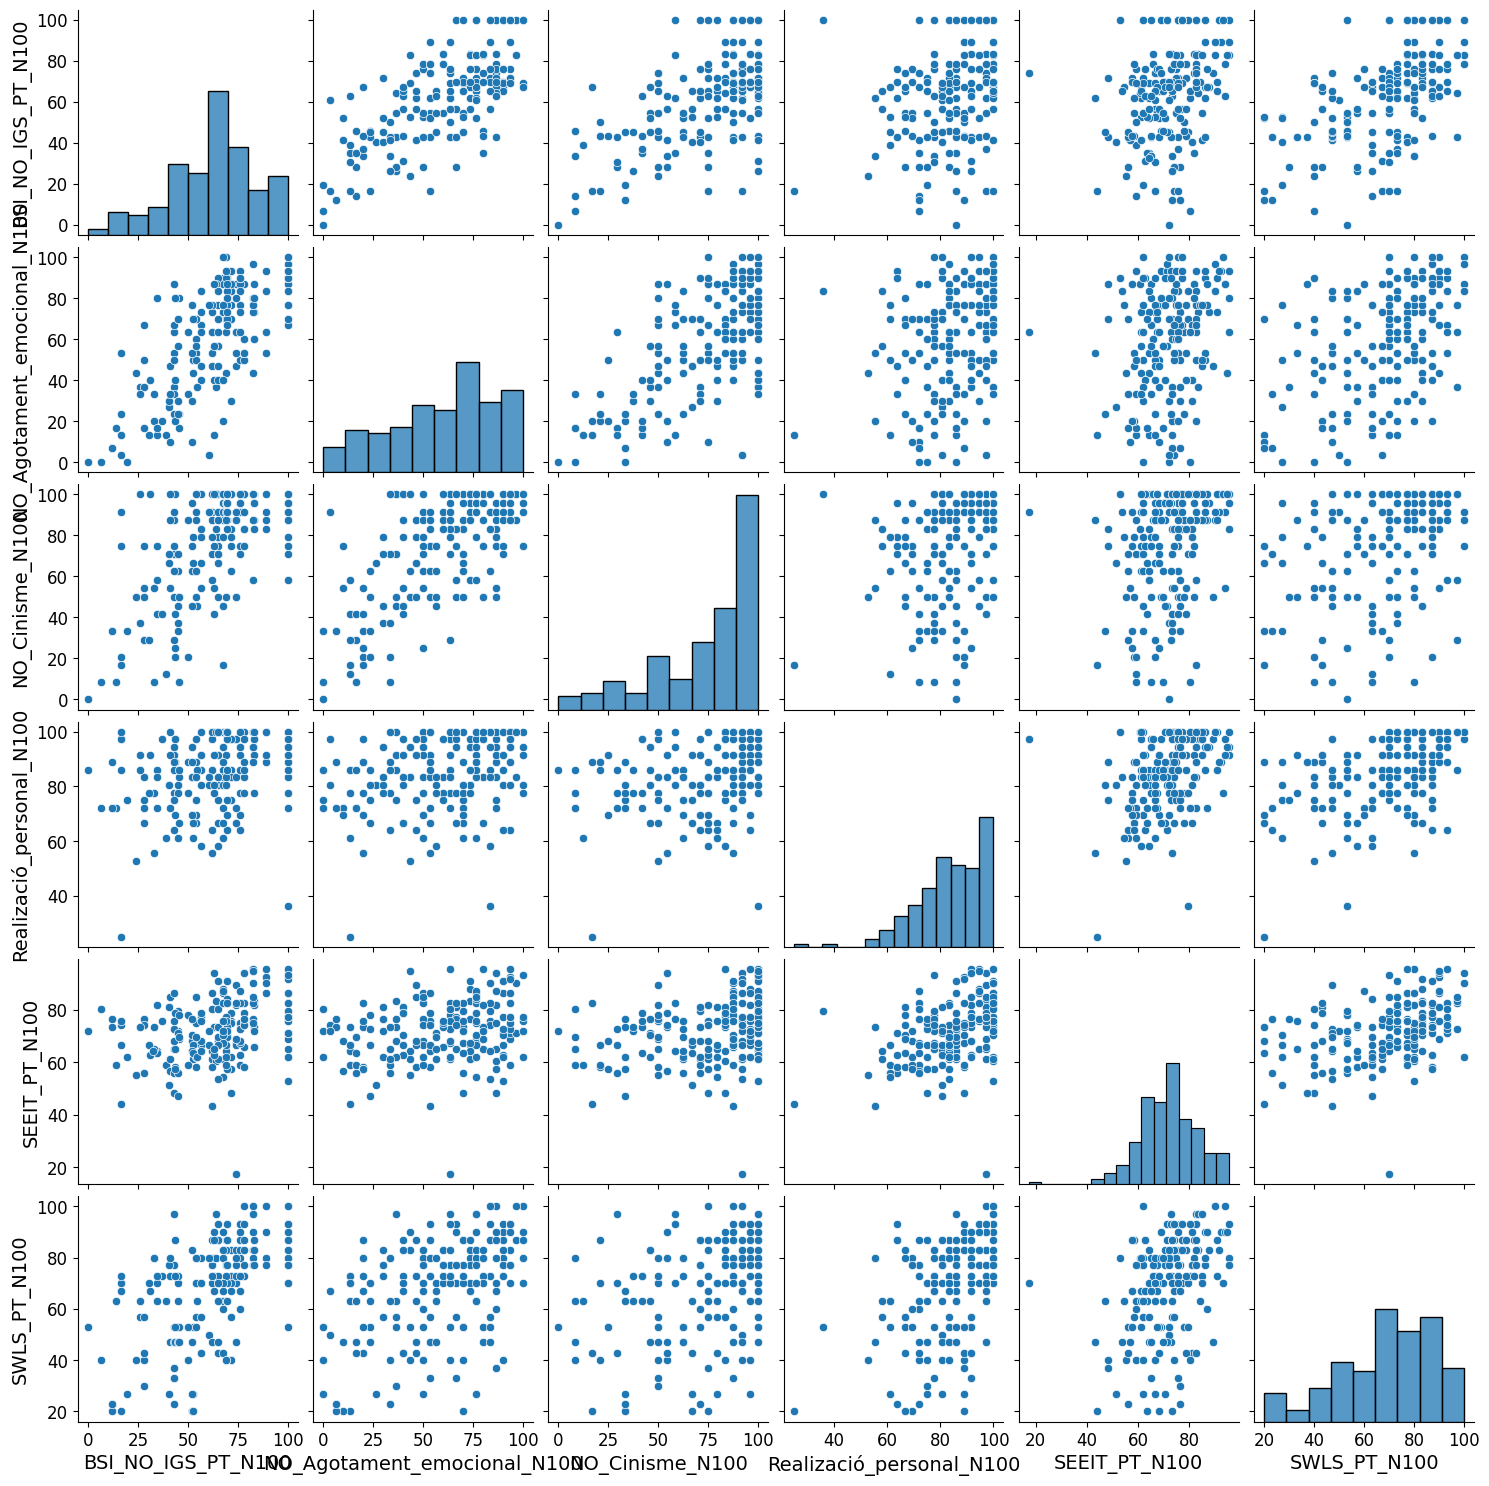

In [8]:
## Pairplot for numeric variables
numericas = [col for col in ARS.columns if  col in ARS and col != 'ID']

cols = [col for col in ARS[numericas]]
g = sns.pairplot(ARS[cols])

for ax in g.axes.flatten():
    plt.setp(ax.get_xticklabels(), fontsize=12)
    plt.setp(ax.get_yticklabels(), fontsize=12)
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)  
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)


In [9]:
## detecting multicollinearity for numeric variables

def detectar_multicolinearidad_numericas(df, numericas, threshold=0.99):
    print("=== DETECTION OF MULTICOLLINEARITY (Spearman) ===")
    print(f"Numeric variables: {len(numericas)}")

    resultados = {
        'numerica_numerica': [],
        'variables_a_eliminar': []
    }

    # 1. NUMERIC vs NUMERIC (perfect correlation)
    print("\n=== 1. REDUNDANT NUMERIC VARIABLES ===")
    if len(numericas) > 1:
        corr_matrix = df[numericas].corr(method='spearman')  
        for i in range(len(numericas)):
            for j in range(i+1, len(numericas)):
                corr_value = corr_matrix.iloc[i, j]
                if abs(corr_value) >= threshold:  # Almost perfect correlation
                    var1 = numericas[i]
                    var2 = numericas[j]
                    resultados['numerica_numerica'].append({
                        'Variable_1': var1,
                        'Variable_2': var2,
                        'Correlacion': corr_value
                    })
                    print(f"  • {var1} ↔ {var2}: r = {corr_value:.3f}")

    # 2. CREATE LIST OF VARIABLES TO REMOVE
    variables_a_eliminar = []
    for par in resultados['numerica_numerica']:
        if par['Variable_2'] not in variables_a_eliminar:
            variables_a_eliminar.append(par['Variable_2'])

    print(f"\n=== FINAL SUMMARY ===")
    print(f"Original variables: {len(df.columns)}")
    print(f"  - Numeric: {len(numericas)}")
    print(f"Redundant variables found: {len(variables_a_eliminar)}")
    print(f"Final variables: {len(df.columns) - len(variables_a_eliminar)}")

    if variables_a_eliminar:
        print(f"\nVariables to remove:")
        for var in variables_a_eliminar:
            print(f"  - {var}")

    resultados['variables_a_eliminar'] = variables_a_eliminar
    return resultados

# Run the function only with numeric variables
resultados_multicolinearidad = detectar_multicolinearidad_numericas(ARS_df, numericas)

=== DETECTION OF MULTICOLLINEARITY (Spearman) ===
Numeric variables: 6

=== 1. REDUNDANT NUMERIC VARIABLES ===

=== FINAL SUMMARY ===
Original variables: 7
  - Numeric: 6
Redundant variables found: 0
Final variables: 7


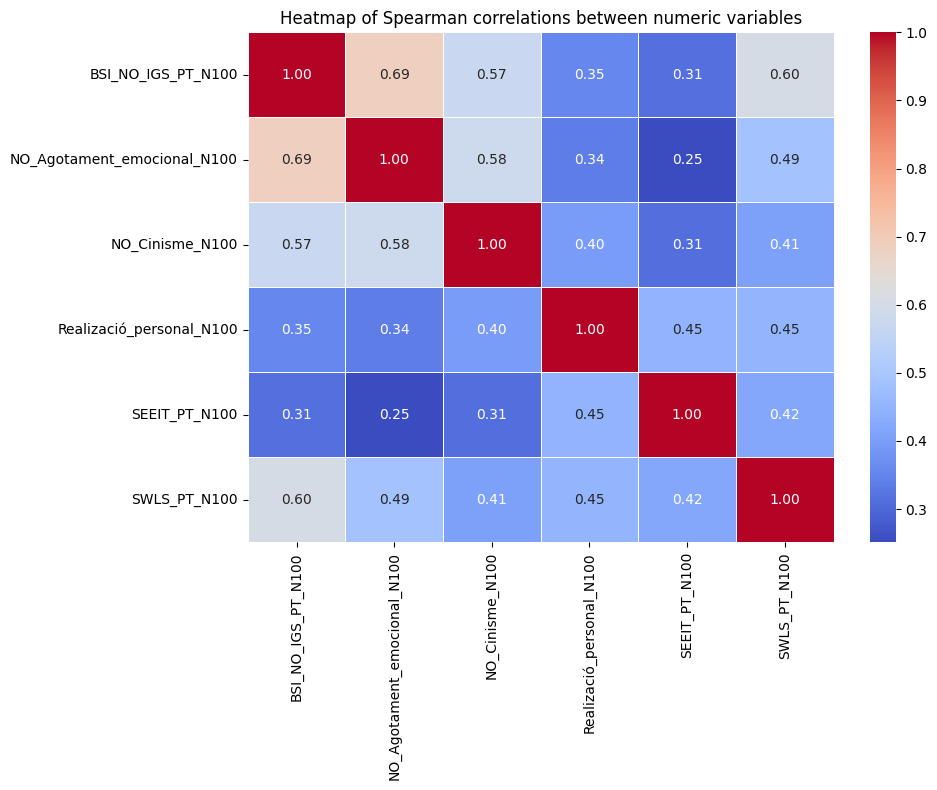

In [10]:
# Calculate the Spearman correlation matrix
corr_matrix = ARS[numericas].corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap of Spearman correlations between numeric variables')
plt.tight_layout()
plt.show()

In [11]:
## Descriptive analysis with outlier detection for numeric variables

def advanced_descriptive_analysis(df, numericas):
    print("=== ADVANCED DESCRIPTIVE ANALYSIS ===")
    
    vars_num = df[numericas]
    
    if len(vars_num.columns) > 0:
        print(f"\n--- NUMERIC VARIABLES ({len(vars_num.columns)}) ---")
        print("\n--- OUTLIER DETECTION ---")
        for col in vars_num.columns:
            Q1 = vars_num[col].quantile(0.2)
            Q3 = vars_num[col].quantile(0.8)
            IQR = Q3 - Q1
            outliers = vars_num[(vars_num[col] < Q1 - 1.5*IQR) | (vars_num[col] > Q3 + 1.5*IQR)]
            print()
            print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(vars_num)*100:.1f}%)")
            # Search for IDs in the original DataFrame if not in vars_num
            if len(outliers) > 0:
                if 'ID' in outliers.columns:
                    ids_out = outliers['ID'].tolist()
                elif 'ID' in df.columns:
                    ids_out = df.loc[outliers.index, 'ID'].tolist()
                else:
                    ids_out = []
                print("  IDs con outlier:")
                print(ids_out)
                print()

# Before calling the function, make sure 'ID' is in students_df
if 'ID' in ARS.columns and 'ID' not in ARS_df.columns:
    ARS_df['ID'] = ARS['ID']

advanced_descriptive_analysis(ARS_df, numericas)

=== ADVANCED DESCRIPTIVE ANALYSIS ===

--- NUMERIC VARIABLES (6) ---

--- OUTLIER DETECTION ---

BSI_NO_IGS_PT_N100: 0 outliers (0.0%)

NO_Agotament_emocional_N100: 0 outliers (0.0%)

NO_Cinisme_N100: 0 outliers (0.0%)

Realizació_personal_N100: 2 outliers (1.1%)
  IDs con outlier:
[40.0, 686.0]


SEEIT_PT_N100: 1 outliers (0.5%)
  IDs con outlier:
[380.0]


SWLS_PT_N100: 0 outliers (0.0%)


In [12]:
from collections import Counter, defaultdict

def ids_outliers_repetidos(df, numericas):
    from collections import defaultdict
    id_vars = defaultdict(list)
    for col in numericas:
        if col in df.columns:
            Q1 = df[col].quantile(0.2)
            Q3 = df[col].quantile(0.8)
            IQR = Q3 - Q1
            outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
            if 'ID' in outliers.columns:
                for id_ in outliers['ID']:
                    id_vars[id_].append(col)
    ids_repetidos = {k: v for k, v in id_vars.items() if len(v) > 1}
    print("IDs that appear as outliers in more than one variable:")
    if ids_repetidos:
        for id_, vars_ in ids_repetidos.items():
            print(f"ID: {id_} - {len(vars_)} veces - Variables: {vars_}")
        return ids_repetidos
    else:
        print("No outliers.")
        return None

# Ejecutar la función
ids_outliers_repetidos(ARS_df, numericas)
outliers_grup_1 = ids_outliers_repetidos(ARS_df, numericas)


IDs that appear as outliers in more than one variable:
No outliers.
IDs that appear as outliers in more than one variable:
No outliers.
